# Visualizing Gender Patterns in the Global Workforce


---
## Setup: Imports & Data Loading; Data Prepartion

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pycountry

# ── ISO3 country code function ────────────────────────────────
def iso3(name):
    overrides = {
        'Korea, Republic of': 'KOR', 'Russian Federation': 'RUS',
        'Yemen, Republic of': 'YEM', 'Ethiopia, The Federal Democratic Republic of': 'ETH',
        'Belarus, Republic of': 'BLR', 'Iran, Islamic Republic of': 'IRN',
        'Tanzania, United Republic of': 'TZA', 'Congo, Democratic Republic of the': 'COD',
        'Venezuela, República Bolivariana de': 'VEN', 'Türkiye, Republic of': 'TUR',
        'Mozambique, Republic of': 'MOZ', 'Moldova, Republic of': 'MDA',
        'Kosovo, Republic of': 'XKX', 'Tajikistan, Republic of': 'TJK',
        'Kazakhstan, Republic of': 'KAZ', 'Armenia, Republic of': 'ARM',
        'Azerbaijan, Republic of': 'AZE', 'Serbia, Republic of': 'SRB',
        'Netherlands, The': 'NLD', 'Poland, Republic of': 'POL',
        'Afghanistan, Islamic Republic of': 'AFG', 'Egypt, Arab Republic of': 'EGY',
        'Slovak Republic': 'SVK', 'Kyrgyz Republic': 'KGZ',
        "Lao People's Democratic Republic": 'LAO', 'Syrian Arab Republic': 'SYR',
        'Cabo Verde': 'CPV', "Cote d'Ivoire": 'CIV',
        'Gambia, The': 'GMB', 'Bahrain, Kingdom of': 'BHR',
        'Brunei Darussalam': 'BRN', 'Lesotho, Kingdom of': 'LSO',
        'Eswatini, Kingdom of': 'SWZ', 'North Macedonia, Republic of': 'MKD',
        'Slovenia, Republic of': 'SVN', 'Croatia, Republic of': 'HRV',
        'Lithuania, Republic of': 'LTU', 'Latvia, Republic of': 'LVA',
        'Estonia, Republic of': 'EST', 'Madagascar, Republic of': 'MDG',
        'Fiji, Republic of': 'FJI', 'Uzbekistan, Republic of': 'UZB',
        'Timor-Leste, Democratic Republic of': 'TLS',
        "Hong Kong Special Administrative Region, People's Republic of China": 'HKG',
        "Macao Special Administrative Region, People's Republic of China": 'MAC',
        'Mauritania, Islamic Republic of': 'MRT', 'Vietnam': 'VNM',
        'Congo, Republic of': 'COG', 'South Sudan, Republic of': 'SSD',
        'Comoros, Union of the': 'COM', 'Equatorial Guinea, Republic of': 'GNQ',
        'Central African Republic': 'CAF', 'Guinea-Bissau': 'GNB',
        'West Bank and Gaza': 'PSE', 'Taiwan': 'TWN',
        'Sao Tome and Principe, Democratic Republic of': 'STP',
    }
    if name in overrides:
        return overrides[name]
    try:
        return pycountry.countries.search_fuzzy(name)[0].alpha_3
    except:
        return name[:3].upper()

get_country_code = iso3

# ── Clean country name function ───────────────────────────────
def clean_country_name(name):
    overrides = {
        'Korea, Republic of': 'South Korea',
        "Korea, Democratic People's Republic of": 'North Korea',
        'Russian Federation': 'Russia',
        'Iran, Islamic Republic of': 'Iran',
        'Syrian Arab Republic': 'Syria',
        'Tanzania, United Republic of': 'Tanzania',
        'Congo, Democratic Republic of the': 'DR Congo',
        'Congo, Republic of': 'Congo',
        'Ethiopia, The Federal Democratic Republic of': 'Ethiopia',
        'Turkiye, Republic of': 'Turkey',
        'Venezuela, Republica Bolivariana de': 'Venezuela',
        "Hong Kong Special Administrative Region, People's Republic of China": 'Hong Kong',
        "Macao Special Administrative Region, People's Republic of China": 'Macao',
        "Lao People's Democratic Republic": 'Laos',
        'Timor-Leste, Democratic Republic of': 'Timor-Leste',
        'Gambia, The': 'Gambia', 'Bahamas, The': 'Bahamas',
        'Netherlands, The': 'Netherlands',
        'Sao Tome and Principe, Democratic Republic of': 'Sao Tome & Principe',
        'Comoros, Union of the': 'Comoros',
        'West Bank and Gaza': 'West Bank & Gaza',
        'Cabo Verde': 'Cape Verde', "Cote d'Ivoire": 'Ivory Coast',
        'South Sudan, Republic of': 'South Sudan',
        'Central African Republic': 'Central African Rep.',
        'Eswatini, Kingdom of': 'Eswatini',
        'Afghanistan, Islamic Republic of': 'Afghanistan',
        'Belarus, Republic of': 'Belarus', 'Moldova, Republic of': 'Moldova',
        'Serbia, Republic of': 'Serbia', 'Kosovo, Republic of': 'Kosovo',
        'Armenia, Republic of': 'Armenia', 'Azerbaijan, Republic of': 'Azerbaijan',
        'Kazakhstan, Republic of': 'Kazakhstan', 'Tajikistan, Republic of': 'Tajikistan',
        'Uzbekistan, Republic of': 'Uzbekistan', 'Kyrgyz Republic': 'Kyrgyzstan',
        'Slovak Republic': 'Slovakia', 'Yemen, Republic of': 'Yemen',
        'Bahrain, Kingdom of': 'Bahrain', 'Lesotho, Kingdom of': 'Lesotho',
        'Mauritania, Islamic Republic of': 'Mauritania',
        'Mozambique, Republic of': 'Mozambique', 'Madagascar, Republic of': 'Madagascar',
        'Fiji, Republic of': 'Fiji', 'North Macedonia, Republic of': 'North Macedonia',
        'Slovenia, Republic of': 'Slovenia', 'Croatia, Republic of': 'Croatia',
        'Lithuania, Republic of': 'Lithuania', 'Latvia, Republic of': 'Latvia',
        'Estonia, Republic of': 'Estonia', 'Poland, Republic of': 'Poland',
        'Egypt, Arab Republic of': 'Egypt',
        'Equatorial Guinea, Republic of': 'Equatorial Guinea',
    }
    if name in overrides:
        return overrides[name]
    for suffix in [', Republic of', ', Islamic Republic of', ', Kingdom of',
                   ', The', ', Union of', ', Federal Democratic Republic of',
                   ', Democratic Republic of']:
        if name.endswith(suffix):
            name = name.replace(suffix, '')
    return name.strip()

print("Helper functions defined!")

# ── Load clean dataset (2000-2022) ────────────────────────────
df = pd.read_csv("/Users/joe/Downloads/gender_project/gender_clean.csv")

# ── Load extended dataset (1990-2023) for time series ─────────
# Re-melt raw data with wider year range
df_raw = pd.read_csv("/Users/joe/Downloads/gender_project/gender.csv")
year_cols = [str(y) for y in range(1990, 2024)]
id_cols = ['COUNTRY', 'GENDER', 'INDICATOR', 'GS_MS', 'AGE_GROUP',
           'UNIT', 'GS_LI_DS', 'GS_LI_EA', 'GS_LI_ED', 'GS_LI_OCC']
df_long = df_raw.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name='YEAR',
    value_name='VALUE'
)
df_long['YEAR'] = df_long['YEAR'].astype(int)
df_long = df_long.dropna(subset=['VALUE'])
# Add region from clean dataset
region_map = df[['COUNTRY', 'REGION']].drop_duplicates()
df_long = df_long.merge(region_map, on='COUNTRY', how='left')
print(f"Extended dataset: {df_long.shape} | Years: {df_long['YEAR'].min()} to {df_long['YEAR'].max()}")

# ── Region Colors ─────────────────────────────────────────────
region_colors = {
    'Central Asia': '#1f77b4',
    'East & Southeast Asia': '#ff7f0e',
    'Europe': '#2ca02c',
    'Latin America & Caribbean': '#d62728',
    'Middle East & North Africa': '#9467bd',
    'North America': '#8c564b',
    'Oceania': '#e377c2',
    'Russia & Caucasus': '#7f7f7f',
    'South Asia': '#bcbd22',
    'Sub-Saharan Africa': '#17becf'
}

# ── Labor Force Participation (from clean dataset) ────────────
lfp = df[
    (df['INDICATOR'] == 'Labor Force Participation, Modeled ILO Estimate, Rate') &
    (df['AGE_GROUP'] == '15+ yrs') &
    (df['GS_MS'] == 'Not Applicable')
]
lfp_global = lfp.groupby(['YEAR', 'GENDER'])['VALUE'].mean().reset_index()

lfp_region_avg = lfp.groupby(['REGION', 'GENDER'])['VALUE'].mean().reset_index()
lfp_pivot = lfp_region_avg.pivot(
    index='REGION', columns='GENDER', values='VALUE').reset_index()
lfp_pivot.columns.name = None
lfp_pivot['gender_gap'] = lfp_pivot['Female'] - lfp_pivot['Male']
lfp_pivot = lfp_pivot.sort_values('gender_gap')

lfp_country_avg = lfp.groupby(['COUNTRY', 'GENDER', 'REGION'])['VALUE'].mean().reset_index()
lfp_country_pivot = lfp_country_avg.pivot_table(
    index=['COUNTRY', 'REGION'], columns='GENDER', values='VALUE'
).reset_index()
lfp_country_pivot.columns.name = None
lfp_country_pivot['gender_gap'] = lfp_country_pivot['Female'] - lfp_country_pivot['Male']
lfp_country_pivot = lfp_country_pivot.dropna(subset=['gender_gap'])

lfp_region_time_avg = lfp[lfp['GENDER'] == 'Female'].groupby(
    ['REGION', 'YEAR'])['VALUE'].mean().reset_index()

baseline = lfp_region_time_avg[
    lfp_region_time_avg['YEAR'] == 2000
][['REGION', 'VALUE']].rename(columns={'VALUE': 'baseline'})
lfp_normalized = lfp_region_time_avg.merge(baseline, on='REGION')
lfp_normalized['change_from_2000'] = lfp_normalized['VALUE'] - lfp_normalized['baseline']

# Map data
lfp_female_map = lfp_country_pivot[['COUNTRY', 'REGION', 'Female']].copy()
lfp_female_map = lfp_female_map.dropna(subset=['Female'])
lfp_female_map['code'] = lfp_female_map['COUNTRY'].apply(iso3)
lfp_female_map['display_name'] = lfp_female_map['COUNTRY'].apply(clean_country_name)

lfp_ratio_map = lfp_country_pivot[['COUNTRY', 'REGION', 'Female', 'Male']].copy()
lfp_ratio_map['ratio'] = (lfp_ratio_map['Female'] / lfp_ratio_map['Male']) * 100
lfp_ratio_map = lfp_ratio_map.dropna(subset=['ratio'])
lfp_ratio_map['code'] = lfp_ratio_map['COUNTRY'].apply(iso3)
lfp_ratio_map['display_name'] = lfp_ratio_map['COUNTRY'].apply(clean_country_name)

lfp_gap_map = lfp_country_pivot[['COUNTRY', 'REGION', 'gender_gap']].copy()
lfp_gap_map = lfp_gap_map.dropna(subset=['gender_gap'])
lfp_gap_map['gap_abs'] = lfp_gap_map['gender_gap'].abs()
lfp_gap_map['code'] = lfp_gap_map['COUNTRY'].apply(iso3)
lfp_gap_map['display_name'] = lfp_gap_map['COUNTRY'].apply(clean_country_name)

female_vals = lfp_global[lfp_global['GENDER'] == 'Female'].sort_values('YEAR').set_index('YEAR')
male_vals = lfp_global[lfp_global['GENDER'] == 'Male'].sort_values('YEAR').set_index('YEAR')
ratio_df = (female_vals['VALUE'] / male_vals['VALUE'] * 100).reset_index()
ratio_df.columns = ['YEAR', 'ratio']

# ── LFP over time 1990-2023 (extended) ───────────────────────
lfp_ext = df_long[
    (df_long['INDICATOR'] == 'Labor Force Participation, Modeled ILO Estimate, Rate') &
    (df_long['AGE_GROUP'] == '15+ yrs') &
    (df_long['GS_MS'] == 'Not Applicable')
]
lfp_global_ext = lfp_ext.groupby(['YEAR', 'GENDER'])['VALUE'].mean().reset_index()

# ── Unemployment (from clean dataset) ────────────────────────
unemp = df[
    (df['INDICATOR'] == 'Unemployment Rate , Rate') &
    (df['AGE_GROUP'] == 'Not Applicable') &
    (df['GS_MS'] == 'Total')
]
unemp_global = unemp.groupby(['YEAR', 'GENDER'])['VALUE'].mean().reset_index()

unemp_2022 = df[
    (df['INDICATOR'] == 'Unemployment Rate , Rate') &
    (df['AGE_GROUP'] == 'Not Applicable') &
    (df['GS_MS'] == 'Total') &
    (df['GENDER'] == 'Female') &
    (df['YEAR'] == 2022)
].copy()
unemp_2022 = unemp_2022.sort_values('VALUE', ascending=False).head(20)

unemp_avg_map = df[
    (df['INDICATOR'] == 'Unemployment Rate , Rate') &
    (df['AGE_GROUP'] == 'Not Applicable') &
    (df['GS_MS'] == 'Total') &
    (df['GENDER'] == 'Female')
].groupby(['COUNTRY'])['VALUE'].mean().reset_index()
unemp_avg_map['code'] = unemp_avg_map['COUNTRY'].apply(iso3)
unemp_avg_map['display_name'] = unemp_avg_map['COUNTRY'].apply(clean_country_name)

# ── Unemployment over time 1990-2023 (extended) ───────────────
unemp_ext = df_long[
    (df_long['INDICATOR'] == 'Unemployment Rate , Rate') &
    (df_long['AGE_GROUP'] == 'Not Applicable') &
    (df_long['GS_MS'] == 'Total')
]
unemp_global_ext = unemp_ext.groupby(['YEAR', 'GENDER'])['VALUE'].mean().reset_index()

# Top countries female unemployment over time
unemp_top_countries = unemp_ext[
    unemp_ext['GENDER'] == 'Female'
].groupby(['COUNTRY', 'YEAR'])['VALUE'].mean().reset_index()

# ── Wages (from clean dataset) ────────────────────────────────
wage_country = df[
    (df['INDICATOR'] == 'Female To Male Wage Ratio, Private Sector, Mean')
].groupby(['COUNTRY', 'REGION'])['VALUE'].mean().reset_index().rename(
    columns={'VALUE': 'wage_ratio'}
).dropna()
wage_country_sorted = wage_country.sort_values('wage_ratio', ascending=False)

wage_gap = df[
    (df['INDICATOR'] == 'Gender Wage Gap by Occupation, Rate') &
    (df['GS_MS'] == 'Not Applicable') &
    (df['AGE_GROUP'] == 'Not Applicable')
].groupby(['COUNTRY', 'REGION'])['VALUE'].mean().reset_index().rename(
    columns={'VALUE': 'wage_gap'}
).dropna()
wage_gap_sorted = wage_gap.sort_values('wage_gap', ascending=False)
wage_gap_sorted['code'] = wage_gap_sorted['COUNTRY'].apply(iso3)

wage_trend = df[
    (df['INDICATOR'] == 'Female To Male Wage Ratio, Private Sector, Mean')
].groupby('YEAR')['VALUE'].mean().reset_index().rename(columns={'VALUE': 'wage_ratio'})

# ── Wage trend 1990-2023 (extended) ──────────────────────────
wage_trend_ext = df_long[
    (df_long['INDICATOR'] == 'Female To Male Wage Ratio, Private Sector, Mean')
].groupby('YEAR')['VALUE'].mean().reset_index().rename(columns={'VALUE': 'wage_ratio'})

# ── Part-Time & Informal Work ─────────────────────────────────
parttime = df[
    (df['INDICATOR'] == 'Part-Time Employment, Percent of total employment') &
    (df['AGE_GROUP'] == 'Not Applicable') &
    (df['GS_MS'] == 'Not Applicable')
].groupby(['COUNTRY', 'REGION', 'GENDER'])['VALUE'].mean().reset_index()
parttime_pivot = parttime.pivot_table(
    index=['COUNTRY', 'REGION'], columns='GENDER', values='VALUE'
).reset_index()
parttime_pivot.columns.name = None
parttime_pivot['gap'] = parttime_pivot['Female'] - parttime_pivot['Male']
parttime_pivot = parttime_pivot.dropna(subset=['gap'])

informal = df[
    (df['INDICATOR'] == 'Informal Employment by Economic Activity') &
    (df['AGE_GROUP'] == 'Not Applicable') &
    (df['GS_MS'] == 'Not Applicable')
].groupby(['COUNTRY', 'REGION', 'GENDER'])['VALUE'].mean().reset_index()
informal_pivot = informal.pivot_table(
    index=['COUNTRY', 'REGION'], columns='GENDER', values='VALUE'
).reset_index()
informal_pivot.columns.name = None
informal_pivot['gap'] = informal_pivot['Female'] - informal_pivot['Male']
informal_pivot = informal_pivot.dropna(subset=['gap'])

# ── Cross-Indicator Analysis ──────────────────────────────────
lfp_avg = df[
    (df['INDICATOR'] == 'Labor Force Participation, Modeled ILO Estimate, Rate') &
    (df['AGE_GROUP'] == '15+ yrs') &
    (df['GS_MS'] == 'Not Applicable') &
    (df['GENDER'] == 'Female')
].groupby(['COUNTRY', 'REGION'])['VALUE'].mean().reset_index().rename(
    columns={'VALUE': 'lfp_female'})
wage_avg = df[
    (df['INDICATOR'] == 'Female To Male Wage Ratio, Private Sector, Mean')
].groupby('COUNTRY')['VALUE'].mean().reset_index().rename(columns={'VALUE': 'wage_ratio'})
scatter_df = lfp_avg.merge(wage_avg, on='COUNTRY').dropna()
region_comparison = scatter_df.groupby('REGION').agg(
    lfp_female=('lfp_female', 'mean'),
    wage_ratio=('wage_ratio', 'mean')
).reset_index()

print("All data prepared successfully!")
print(f"Clean dataset (2000-2022): {df.shape}")
print(f"Extended dataset (1990-2023): {df_long.shape}")

Helper functions defined!
Extended dataset: (919602, 13) | Years: 1990 to 2023
All data prepared successfully!
Clean dataset (2000-2022): (145261, 13)
Extended dataset (1990-2023): (919602, 13)


In [2]:
wage_gap = df[df["INDICATOR"] == "Gender Wage Gap by Occupation, Rate"]
print("Shape:", wage_gap.shape)
print("Years:", sorted(wage_gap["YEAR"].unique()))
print("Countries:", wage_gap["COUNTRY"].nunique())
print("Gender values:", wage_gap["GENDER"].unique())
print("AGE_GROUP values:", wage_gap["AGE_GROUP"].unique())
print("GS_MS values:", wage_gap["GS_MS"].unique())
print(wage_gap.head())

Shape: (6891, 13)
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Countries: 95
Gender values: ['Not applicable']
AGE_GROUP values: ['Not Applicable']
GS_MS values: ['Not Applicable']
         COUNTRY          GENDER                            INDICATOR  \
134991  Portugal  Not applicable  Gender Wage Gap by Occupation, Rate   
134992     Chile  Not applicable  Gender Wage Gap by Occupation, Rate   
134993  Cambodia  Not applicable  Gender Wage Gap by Occupation, Rate   
134994  Cambodia  Not applicable  Gender Wage Gap by Occupation, Rate   
134995      Peru  Not applicable  Gender Wage Gap by Occupation, Rate   

                 GS_MS       AGE_GROUP UNIT      

In [3]:
unemp_indicators = [i for i in df["INDICATOR"].unique() if "unemploy" in i.lower() or "LU" in i]
for i in unemp_indicators:
    print(i)

Unemployment Rate by Age, Modeled ILO Estimate, Rate
Unemployed Persons, ILO Modeled Estimate, Percent of total labor force
Unemployed Persons, National Estimate, Percent of total labor force
Unemployment Rate by Age, National Estimate, Rate
Unemployment Rate , Rate


In [4]:
indicators = [
    "Labor Force Participation, Modeled ILO Estimate, Rate",
    "Unemployment Rate , Rate", 
    "Gender Wage Gap by Occupation, Rate",
    "Part-Time Employment, Percent of total employment",
    "Informal Employment by Economic Activity"
]

for ind in indicators:
    data = df[df["INDICATOR"] == ind]
    print(f"{ind[:50]}: {data['COUNTRY'].nunique()} countries")

Labor Force Participation, Modeled ILO Estimate, R: 182 countries
Unemployment Rate , Rate: 163 countries
Gender Wage Gap by Occupation, Rate: 95 countries
Part-Time Employment, Percent of total employment: 158 countries
Informal Employment by Economic Activity: 98 countries


In [5]:
import pandas as pd

# Get female gender gap for each indicator per country
lfp = df[
    (df["INDICATOR"] == "Labor Force Participation, Modeled ILO Estimate, Rate") &
    (df["AGE_GROUP"] == "15+ yrs") &
    (df["GS_MS"] == "Not Applicable") &
    (df["GENDER"] == "Female")
].groupby("COUNTRY")["VALUE"].mean().rename("LFP")

unemp = df[
    (df["INDICATOR"] == "Unemployment Rate , Rate") &
    (df["AGE_GROUP"] == "Not Applicable") &
    (df["GS_MS"] == "Total") &
    (df["GENDER"] == "Female")
].groupby("COUNTRY")["VALUE"].mean().rename("Unemployment")

wage = df[
    (df["INDICATOR"] == "Gender Wage Gap by Occupation, Rate") &
    (df["GS_LI_OCC"] == "Total (By ICSO 08 Classification)")
].groupby("COUNTRY")["VALUE"].mean().rename("Wage Gap")

parttime = df[
    (df["INDICATOR"] == "Part-Time Employment, Percent of total employment") &
    (df["GENDER"] == "Female")
].groupby("COUNTRY")["VALUE"].mean().rename("Part-Time")

informal = df[
    (df["INDICATOR"] == "Informal Employment by Economic Activity") &
    (df["GS_LI_EA"] == "Total Agriculture and Non-agriculture") &
    (df["GENDER"] == "Female")
].groupby("COUNTRY")["VALUE"].mean().rename("Informal")

combined = pd.concat([lfp, unemp, wage, parttime, informal], axis=1)
print(combined.corr().round(2))

               LFP  Unemployment  Wage Gap  Part-Time  Informal
LFP           1.00         -0.52      0.23       0.14      0.31
Unemployment -0.52          1.00     -0.20      -0.23     -0.42
Wage Gap      0.23         -0.20      1.00       0.09      0.25
Part-Time     0.14         -0.23      0.09       1.00      0.45
Informal      0.31         -0.42      0.25       0.45      1.00


In [6]:
import pandas as pd

lfp = df[
    (df["INDICATOR"] == "Labor Force Participation, Modeled ILO Estimate, Rate") &
    (df["AGE_GROUP"] == "15+ yrs") &
    (df["GS_MS"] == "Not Applicable") &
    (df["GENDER"] == "Female")
].groupby("COUNTRY")["VALUE"].mean().rename("LFP")

unemp = df[
    (df["INDICATOR"] == "Unemployment Rate , Rate") &
    (df["AGE_GROUP"] == "Not Applicable") &
    (df["GS_MS"] == "Total") &
    (df["GENDER"] == "Female")
].groupby("COUNTRY")["VALUE"].mean().rename("Unemployment")

wage = df[
    (df["INDICATOR"] == "Gender Wage Gap by Occupation, Rate") &
    (df["GS_LI_OCC"] == "Total (By ICSO 08 Classification)")
].groupby("COUNTRY")["VALUE"].mean().rename("Wage Gap")

parttime = df[
    (df["INDICATOR"] == "Part-Time Employment, Percent of total employment") &
    (df["GENDER"] == "Female")
].groupby("COUNTRY")["VALUE"].mean().rename("Part-Time")

informal = df[
    (df["INDICATOR"] == "Informal Employment by Economic Activity") &
    (df["GS_LI_EA"] == "Total Agriculture and Non-agriculture") &
    (df["GENDER"] == "Female")
].groupby("COUNTRY")["VALUE"].mean().rename("Informal")

combined = pd.concat([lfp, unemp, wage, parttime, informal], axis=1)
print(combined.corr().round(2))

               LFP  Unemployment  Wage Gap  Part-Time  Informal
LFP           1.00         -0.52      0.23       0.14      0.31
Unemployment -0.52          1.00     -0.20      -0.23     -0.42
Wage Gap      0.23         -0.20      1.00       0.09      0.25
Part-Time     0.14         -0.23      0.09       1.00      0.45
Informal      0.31         -0.42      0.25       0.45      1.00


In [7]:
wage_gap_raw = df_raw[df_raw["INDICATOR"] == "Gender Wage Gap by Occupation, Rate"]
print(wage_gap_raw["GS_LI_OCC"].unique())

['Total (By ICSO 08 Classification)'
 'Skilled agricultural, forestry and fishery workers (By ICSO 08 Classification)'
 'Not elsewhere classified (By ICSO 88 Classification)'
 'Plant and machine operators, and assemblers (By ICSO 08 Classification)'
 'Craft and related trades workers (By ICSO 08 Classification)'
 'Legislators, senior officials and managers (By ICSO 88 Classification)'
 'Armed forces (By ICSO 88 Classification)'
 'Craft and related trades workers (By ICSO 88 Classification)'
 'Service and sales workers (By ICSO 08 Classification)'
 'Professionals (By ICSO 08 Classification)'
 'Professionals (By ICSO 88 Classification)'
 'Plant and machine operators and assemblers (By ICSO 88 Classification)'
 'Technicians and associate professionals (By ICSO 08 Classification)'
 'Elementary occupations (By ICSO 08 Classification)'
 'Technicians and associate professionals (By ICSO 88 Classification)'
 'Service workers and shop and market sales workers (By ICSO 88 Classification)'
 'Mana

In [8]:
hourly = df_raw[df_raw["INDICATOR"] == "Average Hourly Earnings of Employees"]
print("Shape:", hourly.shape)
print("Countries:", hourly["COUNTRY"].nunique())
print("Gender:", hourly["GENDER"].unique())
year_cols = [str(y) for y in range(1990, 2024)]
hourly_long = hourly.melt(id_vars=["COUNTRY", "GENDER"], value_vars=year_cols, var_name="YEAR", value_name="VALUE")
hourly_long = hourly_long.dropna(subset=["VALUE"])
print("Years with data:", sorted(hourly_long["YEAR"].unique()))
print("Countries with data:", hourly_long["COUNTRY"].nunique())

Shape: (5368, 127)
Countries: 119
Gender: ['Female' 'Total' 'Male']
Years with data: ['1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
Countries with data: 119


In [9]:
print(hourly["UNIT"].unique())
print(hourly["GS_LI_EA"].unique())
print(hourly["GS_LI_OCC"].unique())

['Domestic currency']
['Not Applicable']
['Plant and machine operators, and assemblers (By ICSO 08 Classification)'
 'Skilled agricultural, forestry and fishery workers (By ICSO 08 Classification)'
 'Not elsewhere classified (By ICSO 88 Classification)'
 'Armed forces (By ICSO 88 Classification)'
 'Plant and machine operators and assemblers (By ICSO 88 Classification)'
 'Managers (By ICSO 08 Classification)'
 'Service and sales workers (By ICSO 08 Classification)'
 'Total (By ICSO 08 Classification)'
 'Craft and related trades workers (By ICSO 08 Classification)'
 'Clerical support workers (By ICSO 08 Classification)'
 'Technicians and associate professionals (By ICSO 08 Classification)'
 'Clerks (By ICSO 88 Classification)'
 'Elementary occupations (By ICSO 08 Classification)'
 'Professionals (By ICSO 08 Classification)'
 'Elementary occupations (By ICSO 88 Classification)'
 'Professionals (By ICSO 88 Classification)'
 'Skilled agricultural and fishery workers (By ICSO 88 Classificati

In [10]:
private = df[df["INDICATOR"] == "Female To Male Wage Ratio, Private Sector, Mean"]
public = df[df["INDICATOR"] == "Female To Male Wage Ratio, Public Sector, Mean"]

print("Private — Countries:", private["COUNTRY"].nunique(), "| Years:", private["YEAR"].min(), "to", private["YEAR"].max())
print("Public — Countries:", public["COUNTRY"].nunique(), "| Years:", public["YEAR"].min(), "to", public["YEAR"].max())
print("Private Gender:", private["GENDER"].unique())
print("Public Gender:", public["GENDER"].unique())


Private — Countries: 114 | Years: 2000 to 2022
Public — Countries: 113 | Years: 2000 to 2022
Private Gender: ['Not applicable']
Public Gender: ['Not applicable']


In [11]:
unemp = df[
    (df["INDICATOR"] == "Unemployment Rate , Rate") &
    (df["AGE_GROUP"] == "Not Applicable") &
    (df["GS_MS"] == "Total")
]
print("Countries:", unemp["COUNTRY"].nunique())
print("Gender:", unemp["GENDER"].unique())
print("Years:", unemp["YEAR"].min(), "to", unemp["YEAR"].max())


Countries: 134
Gender: ['Male' 'Female']
Years: 2000 to 2022


In [12]:
indicators = [
    "Informal Employment, Rate",
    "Informal Employment",
    "Informal Employment by Economic Activity",
    "Part-Time Employment, Percent of total employment"
]

for ind in indicators:
    data = df[df["INDICATOR"] == ind]
    print(f"\n{ind}")
    print(f"  Countries: {data['COUNTRY'].nunique()}")
    print(f"  Gender: {data['GENDER'].unique()}")
    print(f"  Years: {data['YEAR'].min()} to {data['YEAR'].max()}")
    print(f"  AGE_GROUP: {data['AGE_GROUP'].unique()}")
    print(f"  GS_LI_EA: {data['GS_LI_EA'].unique()[:3]}")


Informal Employment, Rate
  Countries: 0
  Gender: []
  Years: nan to nan
  AGE_GROUP: []
  GS_LI_EA: []

Informal Employment
  Countries: 0
  Gender: []
  Years: nan to nan
  AGE_GROUP: []
  GS_LI_EA: []

Informal Employment by Economic Activity
  Countries: 98
  Gender: ['Female' 'Male']
  Years: 2000 to 2022
  AGE_GROUP: ['Not Applicable']
  GS_LI_EA: ['Non-agriculture' 'Total Agriculture and Non-agriculture' 'Agriculture']

Part-Time Employment, Percent of total employment
  Countries: 158
  Gender: ['Male' 'Female']
  Years: 2000 to 2022
  AGE_GROUP: ['Not Applicable']
  GS_LI_EA: ['Not Applicable']


---
# 1. Labor Force Participation

## Global Female vs Male Labor Force Participation (2000–2022)

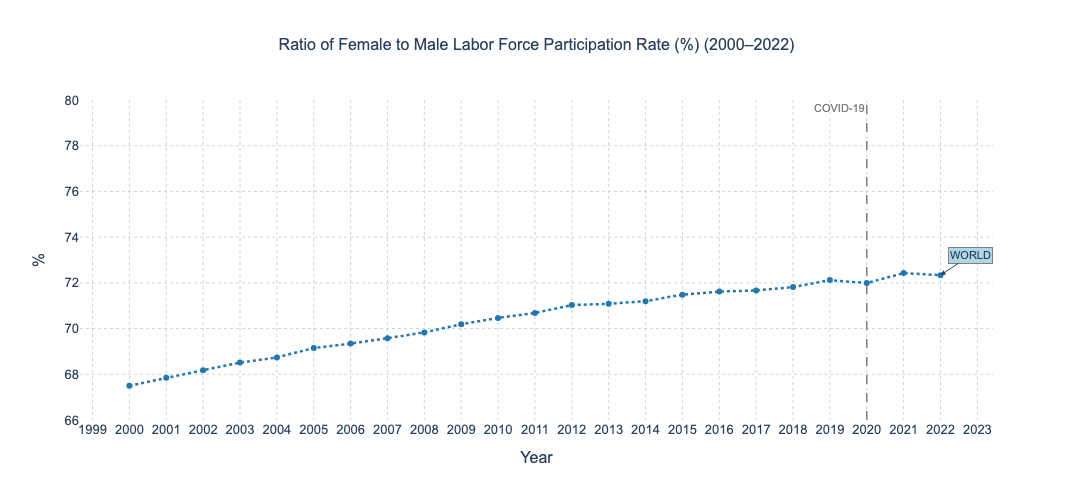

In [13]:
# Chart 1 — Global Female vs Male Labor Force Participation (2000–2022)
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ratio_df['YEAR'],
    y=ratio_df['ratio'],
    mode='lines+markers',
    line=dict(color='#1f77b4', width=2.5, dash='dot'),
    marker=dict(size=6),
    hovertemplate='Year: %{x}<br>Ratio: %{y:.1f}%<extra></extra>',
    name='Female-to-Male Ratio'
))

# COVID annotation
fig.add_vline(
    x=2020,
    line_dash='dash',
    line_color='grey',
    line_width=1.5,
    annotation_text='COVID-19',
    annotation_position='top left',
    annotation_font=dict(size=11, color='grey')
)

fig.update_layout(
    height=500,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    title=dict(
        text='Ratio of Female to Male Labor Force Participation Rate (%) (2000–2022)',
        font=dict(size=16),
        x=0.5
    ),
    xaxis=dict(
        title='Year',
        tickmode='linear',
        tick0=2000,
        dtick=1,              
        gridcolor='lightgrey',
        gridwidth=1,
        griddash='dot'        # dashed grid lines like World Bank
    ),
    yaxis=dict(
        title='%',
        gridcolor='lightgrey',
        gridwidth=1,
        griddash='dot',
        range=[66, 80]        
    ),
    showlegend=False
)

# Add WORLD label at end of line
fig.add_annotation(
    x=2022,
    y=ratio_df[ratio_df['YEAR'] == 2022]['ratio'].values[0],
    text='WORLD',
    showarrow=True,
    arrowhead=2,
    ax=30,
    ay=-20,
    font=dict(size=11),
    bgcolor='lightblue',
    bordercolor='grey',
    borderwidth=1
)

fig.show()

## Gender Gap in Labor Participation by Region

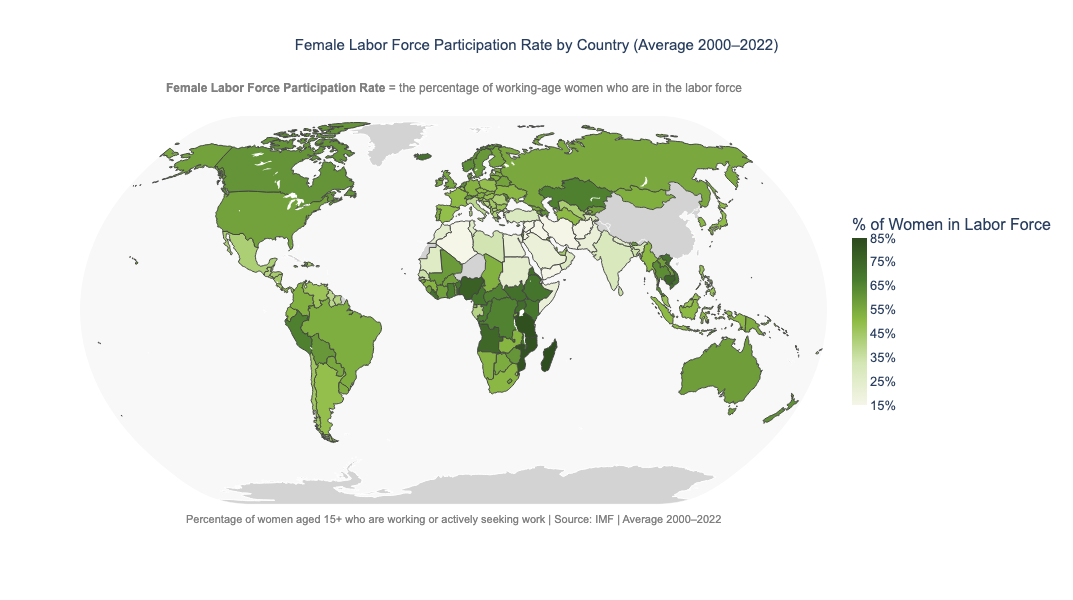

In [14]:
# Choropleth World Map — Female Labor Force Participation Rate (Static)
fig = px.choropleth(
    lfp_female_map,
    locations='code',
    color='Female',
    hover_name='COUNTRY',
    color_continuous_scale=[
        [0, '#f5f5e8'],
        [0.25, '#d4e6b5'],
        [0.5, '#8fbc45'],
        [0.75, '#4a7c2f'],
        [1.0, '#2d4a1e']
    ],
    range_color=[15, 85],
    title='Female Labor Force Participation Rate by Country (Average 2000–2022)',
    labels={'Female': 'Female Participation Rate (%)', 'code': 'Country'},
    hover_data={'code': False, 'Female': ':.1f'}
)

fig.update_layout(
    height=600,
    width=1200,
    dragmode=False,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='white',
        showland=True,
        landcolor='lightgrey',
        showocean=True,
        oceancolor='#f8f8f8',
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(
        title='% of Women in Labor Force',
        tickvals=[15, 25, 35, 45, 55, 65, 75, 85],
        ticktext=['15%', '25%', '35%', '45%', '55%', '65%', '75%', '85%'],
        len=0.5,
        thickness=15
    ),
    title=dict(font=dict(size=15), x=0.5),
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    annotations=[
        dict(
            text='<b>Female Labor Force Participation Rate</b> = the percentage of working-age women who are in the labor force',
            x=0.5, y=1.05,
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=12, color='grey'),
            align='center'
        ),
        dict(
            text='Percentage of women aged 15+ who are working or actively seeking work | Source: IMF | Average 2000–2022',
            x=0.5, y=-0.02,
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=11, color='grey'),
            align='center'
        )
    ]
)

fig.update_geos(
    visible=True,
    resolution=110,
    showcountries=True,
    countrycolor='white',
    countrywidth=0.5
)

fig.show()

# 2. Unemployment

## Female vs Male Unemployment Rate — Global Average Over Time


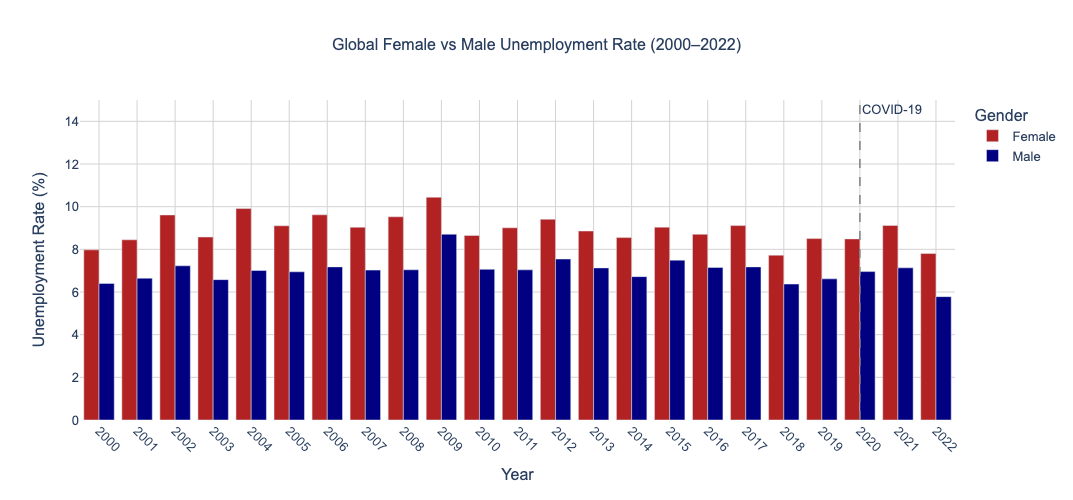

In [15]:
# Female vs Male Unemployment Rate
fig = px.bar(
    unemp_global,
    x='YEAR', y='VALUE', color='GENDER',
    barmode='group',
    color_discrete_map={'Female': 'firebrick', 'Male': 'navy'},
    title='Global Female vs Male Unemployment Rate (2000–2022)',
    labels={'VALUE': 'Unemployment Rate (%)', 'YEAR': 'Year', 'GENDER': 'Gender'}
)
fig.update_layout(
    height=500, plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13), title=dict(font=dict(size=16), x=0.5),
    xaxis=dict(tickmode='linear', tick0=2000, dtick=1, tickangle=45, gridcolor='lightgrey'),
    yaxis=dict(gridcolor='lightgrey', range=[0, 15]),
    legend=dict(title='Gender')
)
fig.add_vline(x=2020, line_dash='dash', line_color='grey', line_width=1.5,
    annotation_text='COVID-19', annotation_position='top right')
fig.show()

## Countries With Highest Female Unemployment in 2022

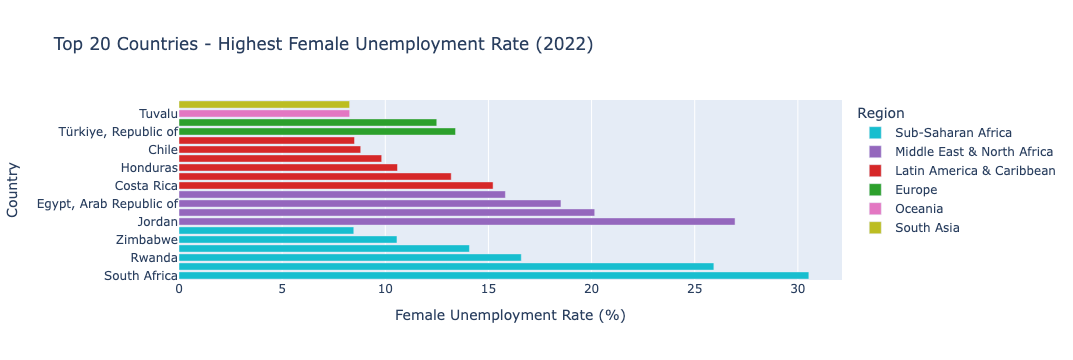

In [16]:
# Countries With Highest Female Unemployment in 2022
fig = px.bar(
    unemp_2022, x='VALUE', y='COUNTRY', orientation='h', color='REGION',
    title='Top 20 Countries - Highest Female Unemployment Rate (2022)',
    labels={'VALUE': 'Female Unemployment Rate (%)', 'COUNTRY': 'Country', 'REGION': 'Region'}
)
fig.update_traces(texttemplate='%{x:.1f}%', textposition='outside',
    hovertemplate='<b>%{y}</b><br>Female Unemployment: %{x:.1f}%<extra></extra>')
fig.update_layout(
    height=600, plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13), title=dict(font=dict(size=16), x=0.5),
    xaxis=dict(gridcolor='lightgrey', range=[0, 38]),
    yaxis=dict(gridcolor='lightgrey', categoryorder='total ascending'),
    legend=dict(title='Region', bgcolor='white', bordercolor='lightgrey', borderwidth=1)
)
fig = px.bar(
    unemp_2022, x='VALUE', y='COUNTRY', orientation='h', color='REGION',
    color_discrete_map=region_colors,  # uses your defined region_colors dict
    title='Top 20 Countries - Highest Female Unemployment Rate (2022)',
    labels={'VALUE': 'Female Unemployment Rate (%)', 'COUNTRY': 'Country', 'REGION': 'Region'}
)
region_colors = {
    'Central Asia': '#1f77b4',
    'East & Southeast Asia': '#ff7f0e',
    'Europe': '#2ca02c',
    'Latin America & Caribbean': '#d62728',
    'Middle East & North Africa': '#9467bd',
    'North America': '#8c564b',
    'Oceania': '#e377c2',
    'Russia & Caucasus': '#7f7f7f',
    'South Asia': '#bcbd22',
    'Sub-Saharan Africa': '#17becf'
}
fig.show()

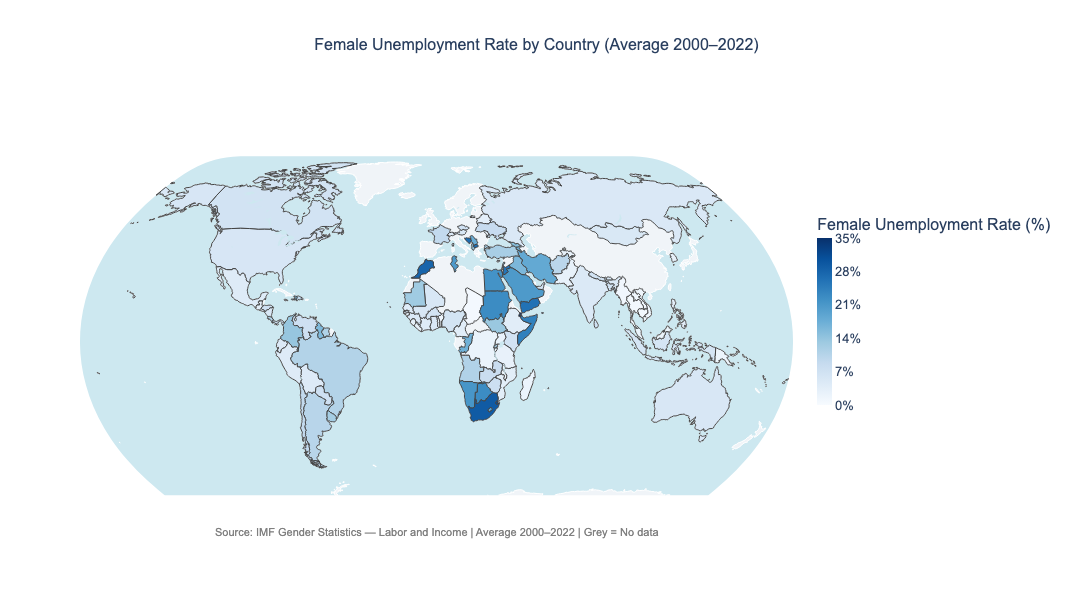

In [17]:
# Choropleth Map — Female Unemployment Rate by Country (Average 2000–2022)
fig = px.choropleth(
    unemp_avg_map,
    locations='code',
    color='VALUE',
    hover_name='COUNTRY',
    color_continuous_scale='Blues',
    range_color=[0, 35],
    title='Female Unemployment Rate by Country (Average 2000–2022)',
    labels={'VALUE': 'Female Unemployment Rate (%)', 'code': 'Country'},
    hover_data={'code': False, 'VALUE': ':.1f'}
)

fig.update_layout(
    height=600,
    width=1200,    # add this
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='white',
        showland=True,
        landcolor='#f0f4f8',
        showocean=True,
        oceancolor='#cde8f0',
        projection_type='natural earth',
        showlakes=True,
        lakecolor='#cde8f0',
        fitbounds='locations'  # add this — zooms map to fit your data
    ),
    coloraxis_colorbar=dict(
        title='Female Unemployment Rate (%)',
        tickvals=[0, 7, 14, 21, 28, 35],
        ticktext=['0%', '7%', '14%', '21%', '28%', '35%'],
        len=0.5,
        thickness=15
    ),
    title=dict(font=dict(size=16), x=0.5),
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    annotations=[
        dict(
            text='Source: IMF Gender Statistics — Labor and Income | Average 2000–2022 | Grey = No data',
            x=0.5, y=-0.05,
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=11, color='grey')
        )
    ]
)

fig.show()

---
# 3. Wages

## Gender Wage Gap by Country

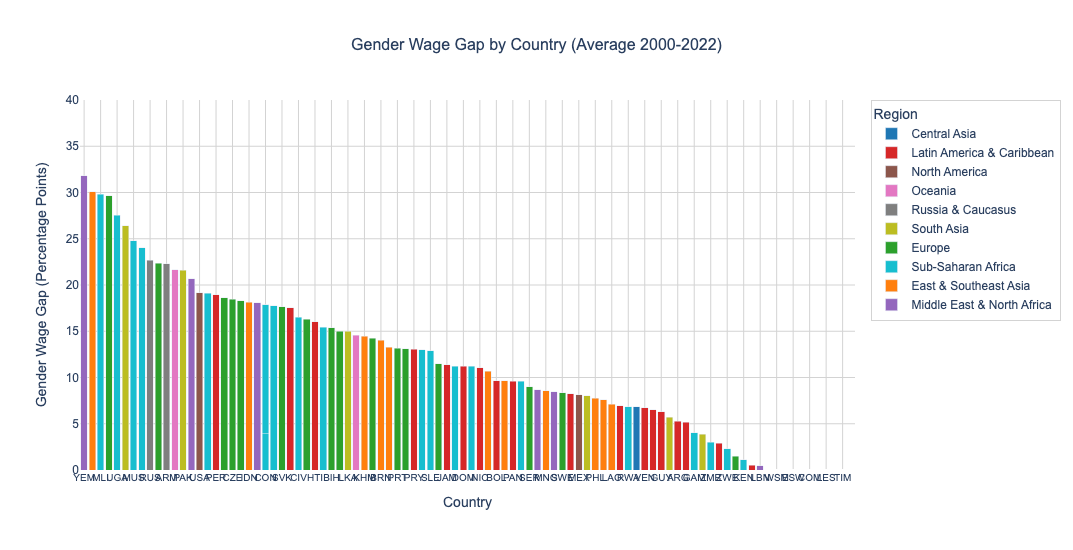

In [18]:
# Gender Wage Gap by Country (OECD Style)
def get_country_code(name):
    overrides = {
        'Korea, Republic of': 'KOR', 'Russian Federation': 'RUS',
        'Yemen, Republic of': 'YEM', 'Ethiopia, The Federal Democratic Republic of': 'ETH',
        'Belarus, Republic of': 'BLR', 'Turkiye, Republic of': 'TUR',
        'Netherlands, The': 'NLD', 'Poland, Republic of': 'POL',
        'Slovak Republic': 'SVK', 'Kosovo, Republic of': 'XKX',
    }
    if name in overrides:
        return overrides[name]
    try:
        return pycountry.countries.search_fuzzy(name)[0].alpha_3
    except:
        return name[:3].upper()

wage_gap_sorted['code'] = wage_gap_sorted['COUNTRY'].apply(get_country_code)
fig = go.Figure()
for region in wage_gap_sorted['REGION'].unique():
    region_data = wage_gap_sorted[wage_gap_sorted['REGION'] == region]
    fig.add_trace(go.Bar(
        x=region_data['code'], y=region_data['wage_gap'], name=region,
        marker_color=region_colors.get(region, 'grey'),
        hovertemplate='<b>%{customdata}</b><br>Wage Gap: %{y:.1f}%<extra></extra>',
        customdata=region_data['COUNTRY']
    ))
fig.update_layout(
    height=550, width=1200, barmode='stack', plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    title=dict(text='Gender Wage Gap by Country (Average 2000-2022)', font=dict(size=16), x=0.5),
    xaxis=dict(title='Country', categoryorder='array',
               categoryarray=wage_gap_sorted['code'].tolist(), tickangle=0,
               gridcolor='lightgrey', tickfont=dict(size=10)),
    yaxis=dict(title='Gender Wage Gap (Percentage Points)', gridcolor='lightgrey',
               range=[0, 40], tickmode='linear', tick0=0, dtick=5),
    legend=dict(title='Region', bgcolor='white', bordercolor='lightgrey', borderwidth=1)
)
fig.show()

## Bottom 20 Countries — Worst Female-to-Male Wage Ratio

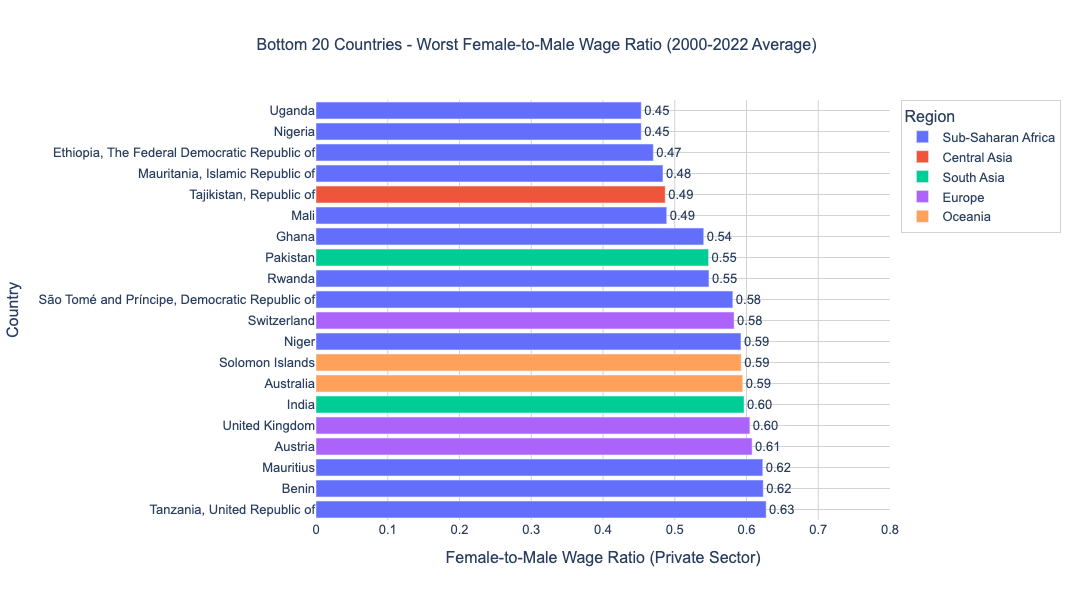

In [19]:
# Bottom 20 Countries: Worst Wage Ratio
bottom20_wage = wage_country_sorted.tail(20).sort_values('wage_ratio')
fig = px.bar(
    bottom20_wage, x='wage_ratio', y='COUNTRY', orientation='h', color='REGION',
    title='Bottom 20 Countries - Worst Female-to-Male Wage Ratio (2000-2022 Average)',
    labels={'wage_ratio': 'Female-to-Male Wage Ratio (Private Sector)', 'COUNTRY': 'Country', 'REGION': 'Region'}
)
fig.update_traces(texttemplate='%{x:.2f}', textposition='outside',
    hovertemplate='<b>%{y}</b><br>Wage Ratio: %{x:.2f}<extra></extra>')
fig.update_layout(
    height=600, plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13), title=dict(font=dict(size=16), x=0.5),
    xaxis=dict(gridcolor='lightgrey', range=[0, 0.8]),
    yaxis=dict(gridcolor='lightgrey', categoryorder='total descending'),
    legend=dict(title='Region', bgcolor='white', bordercolor='lightgrey', borderwidth=1)
)
fig.add_vline(x=1.0, line_dash='dash', line_color='grey', line_width=1.5,
    annotation_text='Perfect equality (1.0)', annotation_position='top right')
fig.show()

## Chart 13: Wage Ratio Trend Over Time

**What this shows:** The global average female-to-male wage ratio from 2000 to 2022. An upward trend means the gap is closing.

**How it is calculated:**
- For each year, all countries' wage ratios are averaged
- The dashed line at 1.0 represents perfect wage equality

**Data source:** `Female To Male Wage Ratio, Private Sector, Mean` | Global average per year

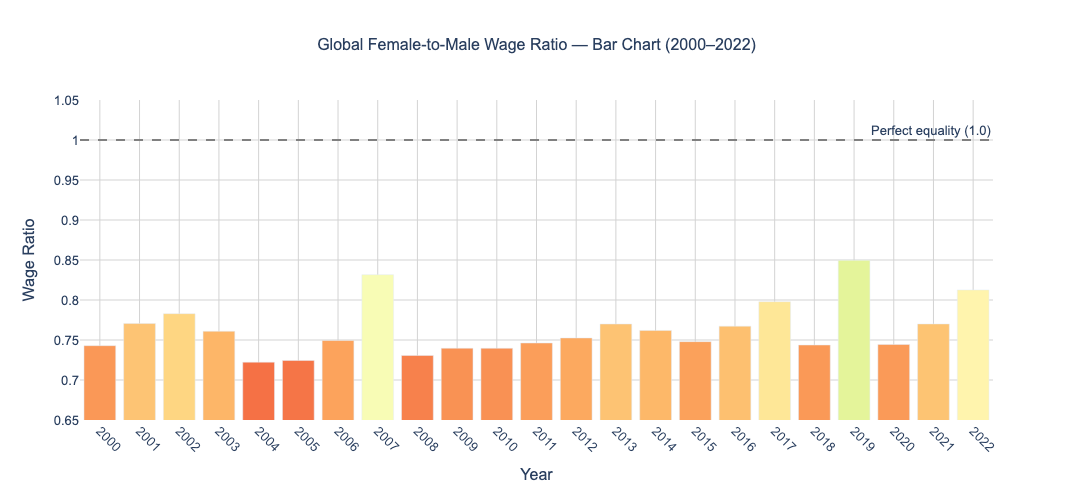

In [20]:
# Bar Chart: Global Wage Ratio Trend Over Time
fig_bar = px.bar(
    wage_trend,
    x='YEAR',
    y='wage_ratio',
    color='wage_ratio',
    color_continuous_scale='RdYlGn',
    range_color=[0.65, 1.0],
    title='Global Female-to-Male Wage Ratio — Bar Chart (2000–2022)',
    labels={'wage_ratio': 'Wage Ratio', 'YEAR': 'Year'}
)
fig_bar.add_hline(y=1.0, line_dash='dash', line_color='grey',
    annotation_text='Perfect equality (1.0)', annotation_position='top right')
fig_bar.update_layout(
    height=500, plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=13), title=dict(font=dict(size=16), x=0.5),
    xaxis=dict(tickmode='linear', tick0=2000, dtick=1, tickangle=45, gridcolor='lightgrey'),
    yaxis=dict(gridcolor='lightgrey', range=[0.65, 1.05]),
    coloraxis_showscale=False
)
fig_bar.show()

---
# 4. Part-Time & Informal Work

## Countries Where Women Dominate Part-Time and Informal Work

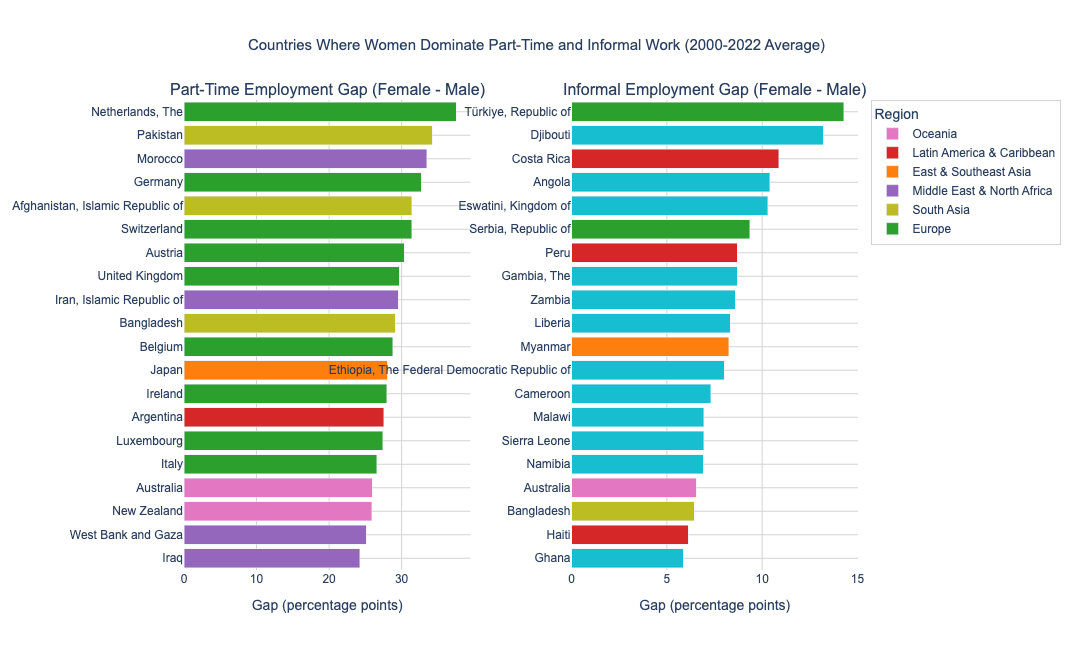

In [21]:
# Chart 14 — Countries Where Women Dominate Part-Time and Informal Work
top20_parttime = parttime_pivot.sort_values('gap', ascending=False).head(20)
top20_informal = informal_pivot.sort_values('gap', ascending=False).head(20)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Part-Time Employment Gap (Female - Male)', 'Informal Employment Gap (Female - Male)'),
    horizontal_spacing=0.15
)
for region in top20_parttime['REGION'].unique():
    region_data = top20_parttime[top20_parttime['REGION'] == region]
    fig.add_trace(go.Bar(
        x=region_data['gap'], y=region_data['COUNTRY'], orientation='h', name=region,
        marker_color=region_colors.get(region, 'grey'),
        hovertemplate='<b>%{y}</b><br>Gap: %{x:.1f} pts<extra></extra>', showlegend=True
    ), row=1, col=1)
for region in top20_informal['REGION'].unique():
    region_data = top20_informal[top20_informal['REGION'] == region]
    fig.add_trace(go.Bar(
        x=region_data['gap'], y=region_data['COUNTRY'], orientation='h', name=region,
        marker_color=region_colors.get(region, 'grey'),
        hovertemplate='<b>%{y}</b><br>Gap: %{x:.1f} pts<extra></extra>', showlegend=False
    ), row=1, col=2)
fig.update_layout(
    height=650, width=1200, barmode='stack', plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    title=dict(text='Countries Where Women Dominate Part-Time and Informal Work (2000-2022 Average)',
               font=dict(size=15), x=0.5),
    legend=dict(title='Region', bgcolor='white', bordercolor='lightgrey', borderwidth=1)
)
fig.update_xaxes(gridcolor='lightgrey', title_text='Gap (percentage points)')
fig.update_yaxes(gridcolor='lightgrey', categoryorder='total ascending')
fig.show()

---
# 5. Cross-Indicator Analysis

## Does Higher Female Participation Imply a Smaller Wage Gap?

In [22]:
import networkx as nx
from pyvis.network import Network
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Prepare data — country profiles across key indicators
# We need one row per country with multiple indicator values as columns

indicators = [
    'Labor Force Participation, Modeled ILO Estimate, Rate',
    'Unemployment Rate , Rate',
    'Female To Male Wage Ratio, Private Sector, Mean'
]

# Get female values for each indicator averaged across years
profiles = []
for indicator in indicators:
    temp = df[
        (df['INDICATOR'] == indicator) &
        (df['GENDER'].isin(['Female', 'Not applicable']))
    ].groupby('COUNTRY')['VALUE'].mean().reset_index()
    temp.columns = ['COUNTRY', indicator[:15]]  # shorten name
    profiles.append(temp)

# Merge all indicators
from functools import reduce
country_profiles = reduce(
    lambda left, right: pd.merge(left, right, on='COUNTRY', how='inner'),
    profiles
)

# Add region
country_profiles = country_profiles.merge(
    df[['COUNTRY', 'REGION']].drop_duplicates(),
    on='COUNTRY', how='left'
)

country_profiles = country_profiles.dropna()
print("Countries with full profiles:", len(country_profiles))
print(country_profiles.head())

Countries with full profiles: 107
                            COUNTRY  Labor Force Par  Unemployment Ra  \
0  Afghanistan, Islamic Republic of        15.604174        11.741862   
1                           Albania        44.420754        16.581213   
2                         Argentina        45.188754         9.530616   
3              Armenia, Republic of        51.693101        18.795510   
4                         Australia        61.062449         5.901914   

   Female To Male                      REGION  
0         0.879716                 South Asia  
1         0.713224                     Europe  
2         0.677925  Latin America & Caribbean  
3         0.683833          Russia & Caucasus  
4         0.594686                    Oceania  


In [23]:
# ── Build Country Similarity Network ─────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from pyvis.network import Network

# Get feature columns only (exclude COUNTRY and REGION)
feature_cols = [c for c in country_profiles.columns if c not in ['COUNTRY', 'REGION']]

# Standardize features so all indicators are on same scale
scaler = StandardScaler()
features_scaled = scaler.fit_transform(country_profiles[feature_cols])

# Calculate cosine similarity between all country pairs
similarity_matrix = cosine_similarity(features_scaled)

# Build NetworkX graph
G = nx.Graph()

# Add nodes — one per country
for _, row in country_profiles.iterrows():
    G.add_node(
        row['COUNTRY'],
        region=row['REGION'],
        lfp=round(row[feature_cols[0]], 1),
        unemp=round(row[feature_cols[1]], 1),
        wage=round(row[feature_cols[2]], 3)
    )

# Add edges — connect countries with similarity above threshold
threshold = 0.95  # only connect very similar countries
countries = country_profiles['COUNTRY'].tolist()

for i in range(len(countries)):
    for j in range(i+1, len(countries)):
        sim = similarity_matrix[i][j]
        if sim >= threshold:
            G.add_edge(countries[i], countries[j], weight=round(sim, 3))

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Average connections per country: {G.number_of_edges()*2/G.number_of_nodes():.1f}")

Nodes: 107
Edges: 208
Average connections per country: 3.9


In [24]:
# ── PyVis Interactive Network ─────────────────────────────────

# Map regions to colors
region_color_map = {
    'Central Asia': '#1f77b4',
    'East & Southeast Asia': '#ff7f0e',
    'Europe': '#2ca02c',
    'Latin America & Caribbean': '#d62728',
    'Middle East & North Africa': '#9467bd',
    'North America': '#8c564b',
    'Oceania': '#e377c2',
    'Russia & Caucasus': '#7f7f7f',
    'South Asia': '#bcbd22',
    'Sub-Saharan Africa': '#17becf'
}

# Create PyVis network
net = Network(
    height='700px',
    width='100%',
    bgcolor='#ffffff',
    font_color='#333333'
)

# Add nodes
for node, attrs in G.nodes(data=True):
    region = attrs.get('region', 'Unknown')
    color = region_color_map.get(region, '#grey')
    display = clean_country_name(node)
    
    net.add_node(
        node,
        label=display,
        color=color,
        title=f"""
            <b>{display}</b><br>
            Region: {region}<br>
            Female LFP: {attrs.get('lfp', 'N/A')}%<br>
            Female Unemployment: {attrs.get('unemp', 'N/A')}%<br>
            Wage Ratio: {attrs.get('wage', 'N/A')}
        """,
        size=20,
        font={'size': 12}
    )

# Add edges
for u, v, attrs in G.edges(data=True):
    net.add_edge(
        u, v,
        width=attrs.get('weight', 1) * 2,
        color='rgba(150,150,150,0.4)'
    )

# Physics settings for better layout
net.set_options("""
{
  "physics": {
    "enabled": true,
    "forceAtlas2Based": {
      "gravitationalConstant": -50,
      "centralGravity": 0.01,
      "springLength": 100,
      "springConstant": 0.08
    },
    "solver": "forceAtlas2Based",
    "stabilization": {"iterations": 150}
  },
  "interaction": {
    "hover": true,
    "tooltipDelay": 100
  }
}
""")

# Save and display
output_path = "/Users/joe/Downloads/gender_project/network.html"
net.save_graph(output_path)
print(f"Network saved to: {output_path}")
print("Open the file in your browser to see the interactive network!")

Network saved to: /Users/joe/Downloads/gender_project/network.html
Open the file in your browser to see the interactive network!


In [25]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("gender_clean.csv")

unemp = df[
    (df["INDICATOR"] == "Unemployment Rate , Rate") &
    (df["AGE_GROUP"] == "Not Applicable") &
    (df["GS_MS"] == "Total") &
    (df["GENDER"] == "Female") &
    (df["YEAR"] == 2022)
]

print(f"Countries with data: {unemp['COUNTRY'].nunique()}")
print(unemp["VALUE"].describe())

Countries with data: 60
count    60.00000
mean      7.80250
std       6.44115
min       0.69300
25%       3.50650
50%       5.34000
75%       9.06325
max      30.53300
Name: VALUE, dtype: float64


In [26]:
# Check wage coverage
wage_2022 = df[
    (df["INDICATOR"] == "Gender Wage Gap by Occupation, Rate") &
    (df["GS_LI_OCC"] == "Total (By ICSO 08 Classification)") &
    (df["YEAR"] == 2022)
]
print(f"Wage countries 2022: {wage_2022['COUNTRY'].nunique()}")
print(wage_2022["VALUE"].describe())

# Check average across all years
wage_avg = df[
    (df["INDICATOR"] == "Gender Wage Gap by Occupation, Rate") &
    (df["GS_LI_OCC"] == "Total (By ICSO 08 Classification)")
].groupby("COUNTRY")["VALUE"].mean().reset_index()
print(f"\nWage countries all years avg: {wage_avg['COUNTRY'].nunique()}")
print(wage_avg["VALUE"].describe())

Wage countries 2022: 43
count    43.000000
mean      6.366000
std      13.483136
min     -24.678000
25%      -0.960000
50%       8.449000
75%      16.392500
max      38.375000
Name: VALUE, dtype: float64

Wage countries all years avg: 91
count    91.000000
mean      6.314565
std      18.233523
min     -90.720500
25%       0.729650
50%       9.536000
75%      17.077054
max      34.489714
Name: VALUE, dtype: float64
